In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [ ]:
import dataset, plots, features
import pandas as pd

sp500_components = dataset.SP500.load_historical()

## Dane cenowe

Do selekcji spółek do portfela z wykorzystaniem analizy technicznej w dłuższym terminie wystarczają wartości uzyskane pod koniec sesji każdego dnia (**End-of-Day, EOD**). Ponieważ dane muszą obejmować również spółki, które już nie istnieją, aby uniknąć błędów badawczych, darmowe źródła często okazują się niewystarczające. W praktyce można przyjąć dwa podejścia:

- pobranie danych cenowych z darmowych źródeł i uzupełnienie brakujących danych profesjonalnym dostawcą

- pobranie wszystkich danych bezpośrednio od profesjonalnego dostawcy.

W tym projekcie wybrane zostało pierwsze podejście, aby zwizualizować potencjalny wpływ brakujących lub niekompletnych danych na wyniki analizy.

### Dane cenowe z Yahoo Finance

Najpopularniejszą opcją pozyskania danych cenowych jest korzystanie z [**Yahoo Finance**](https://finance.yahoo.com/?guccounter=1), np. poprzez bibliotekę [**yfinance**](https://github.com/ranaroussi/yfinance) w Pythonie, która umożliwia pobranie danych historycznych spółek wraz z cenami skorygowanymi o splity i dywidendy.

#### Uzyskanie danych z pojedynczej spółki

Poniżej przykładowe użycie tej biblioteki w celu uzyskania historii cen akcji spółki Apple (AAPL). Dane cenowe zamknięcia (**Adj Close**) są już skorygowane o dywidendy.

In [3]:
apple = dataset.YahooFinance.get_ticker_data_incremental("AAPL", save_csv=True)

plots.summarize_df(apple)

Loading existing data for AAPL from AAPL.csv
Fetching new data for AAPL since 2026-04-02
Updated AAPL with new data
Saved data for AAPL to AAPL.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 11418 entries, 1980-12-12 05:00:00+00:00 to 2026-04-02 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          11418 non-null  float64
 1   High          11418 non-null  float64
 2   Low           11418 non-null  float64
 3   Close         11418 non-null  float64
 4   Adj Close     11418 non-null  float64
 5   Volume        11418 non-null  int64  
 6   Dividends     11418 non-null  float64
 7   Stock Splits  11418 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 802.8+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,11418.00000000,11418.00000000,11418.00000000,11418.00000000,11418.00000000,11418.00000000,11418.00000000,11418.00000000
mean,30.15047309,30.47617352,29.84209861,30.17159160,29.21951545,308284883.56980205,0.00088138,0.00148888
std,60.61079138,61.25882629,60.00924209,60.65893391,60.12135200,333052988.46902442,0.01315022,0.08211036
min,0.04966500,0.04966500,0.04910700,0.04910700,0.03760944,0.00000000,0.00000000,0.00000000
25%,0.30506150,0.31138399,0.29910699,0.30524600,0.24740569,105344100.00000000,0.00000000,0.00000000
50%,0.60714298,0.62053603,0.59654000,0.60686401,0.49609168,197195600.00000000,0.00000000,0.00000000
75%,24.55455351,24.78562546,24.27875042,24.49687481,21.92354155,388321600.00000000,0.00000000,0.00000000
max,286.20001221,288.61999512,283.29998779,286.19000244,285.92245483,7421640800.00000000,0.26000000,7.00000000


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12 05:00:00+00:00,0.12834799,0.12890600,0.12834799,0.12834799,0.09829751,469033600,0.00000000,0.00000000
1980-12-15 05:00:00+00:00,0.12221000,0.12221000,0.12165200,0.12165200,0.09316923,175884800,0.00000000,0.00000000
2026-04-01 04:00:00+00:00,254.08000183,256.17999268,253.33000183,255.63000488,255.63000488,40059400,0.00000000,0.00000000
2026-04-02 00:00:00-04:00,254.19999695,256.13000488,250.64999390,255.91999817,255.91999817,31289400,0.00000000,0.00000000


Poniższy fragment danych — dzień przed, w dniu oraz dzień po splicie akcji — pokazuje, że ceny w danych historycznych uwzględniają już split.

In [4]:
plots.YahooFinance.show_last_split(apple)

,Open,Adj Close,Dividends,Stock Splits
Date,,,,
2020-08-28 04:00:00+00:00,126.01249695,121.17152405,0.00000000,0.00000000
2020-08-31 04:00:00+00:00,127.58000183,125.28070068,0.00000000,4.00000000
2020-09-01 04:00:00+00:00,132.75999451,130.27099609,0.00000000,0.00000000


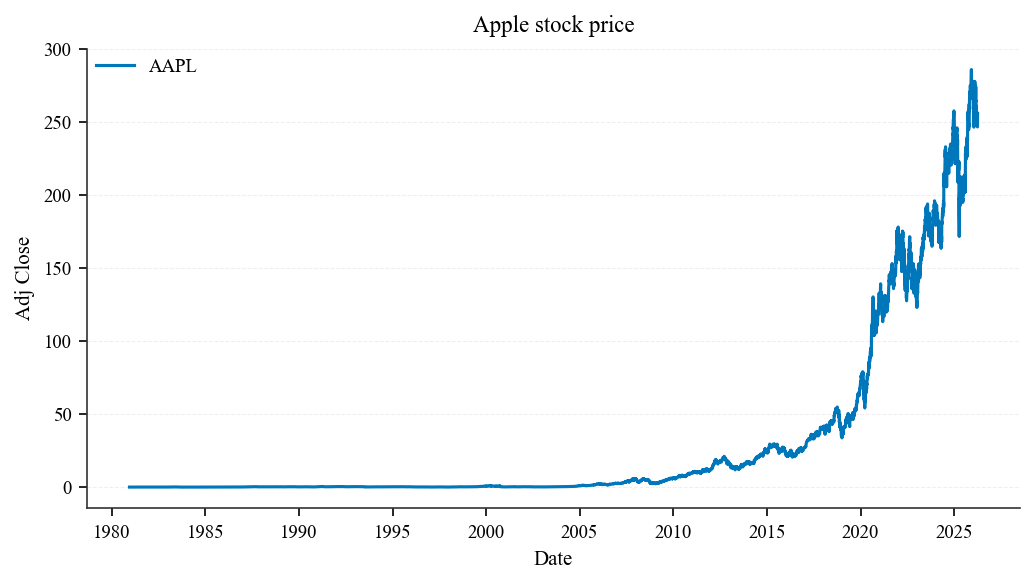

,AAPL
Date,
1980-12-12,0.09829751
1980-12-15,0.09316923
1980-12-16,0.08633084
1980-12-17,0.08846761
1980-12-18,0.09103248
...,...
2026-03-27,248.80000305
2026-03-30,246.63000488
2026-03-31,253.78999329


In [5]:
plots.YahooFinance.show_chart(apple, "AAPL", title="Apple stock price", hide_col=True)

#### Uzyskanie danych o indeksie

Na platformie Yahoo Finance dostępne są różne tickery reprezentujące indeks S&P 500, które różnią się sposobem uwzględniania dywidend:

- **SP500 (^GSPC, S&P 500)** – indeks cenowy (*price return*), uwzględniający wyłącznie zmiany cen akcji spółek wchodzących w skład indeksu
- **SP500TR (^SP500TR, S&P 500 Total Return)** – indeks dochodowy (*total return*), uwzględniający zarówno zmiany cen, jak i reinwestowane dywidendy
- **ETF (CSPX.L, iShares Core S&P 500 UCITS ETF Acc)** – fundusz ETF replikujący indeks S&P 500 w sposób fizyczny, akumulujący dywidendy (reinwestowane wewnątrz funduszu), stanowiący przybliżenie rzeczywistej stopy zwrotu inwestora

Zestawienie tych trzech instrumentów pozwala porównać:
- wpływ dywidend na długoterminową stopę zwrotu,
- różnice między indeksem teoretycznym a rzeczywistym instrumentem inwestycyjnym,
- dokładność odwzorowania indeksu przez ETF (tzw. *tracking error*).

In [6]:
SP500 = dataset.YahooFinance.get_ticker_data_incremental("^GSPC", save_csv=True)
SP500TR = dataset.YahooFinance.get_ticker_data_incremental("^SP500TR", save_csv=True)
ETF = dataset.YahooFinance.get_ticker_data_incremental("CSPX.L", save_csv=True)

plots.summarize_df(SP500)
plots.summarize_df(SP500TR)
plots.summarize_df(ETF)

Loading existing data for ^GSPC from ^GSPC.csv
Fetching new data for ^GSPC since 2026-04-02
Updated ^GSPC with new data
Saved data for ^GSPC to ^GSPC.csv
Loading existing data for ^SP500TR from ^SP500TR.csv
Fetching new data for ^SP500TR since 2026-04-02
Updated ^SP500TR with new data
Saved data for ^SP500TR to ^SP500TR.csv
Loading existing data for CSPX.L from CSPX.L.csv
Fetching new data for CSPX.L since 2026-04-01
Updated CSPX.L with new data
Saved data for CSPX.L to CSPX.L.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 24680 entries, 1927-12-30 05:00:00+00:00 to 2026-04-02 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          24680 non-null  float64
 1   High          24680 non-null  float64
 2   Low           24680 non-null  float64
 3   Close         24680 non-null  float64
 4   Adj Close     24680 non-null  float64
 5   Volume        24680 non-null  int64  
 6   Dividends 

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,24680.00000000,24680.00000000,24680.00000000,24680.00000000,24680.00000000,24680.00000000,24680.00000000,24680.00000000
mean,730.26153161,734.45782536,725.78780959,730.40359304,730.40359304,973990784.44084275,0.00000000,0.00000000
std,1252.78342243,1259.41369616,1245.59611820,1252.96226029,1252.96226029,1691694120.38679338,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,0.00000000,0.00000000
25%,24.95749950,24.95749950,24.95749950,24.95749950,24.95749950,1600000.00000000,0.00000000,0.00000000
50%,103.61500168,104.41999817,102.77500153,103.61000061,103.61000061,22310000.00000000,0.00000000,0.00000000
75%,1093.57254028,1099.52001953,1084.66751099,1093.28497314,1093.28497314,1186597500.00000000,0.00000000,0.00000000
max,7002.00000000,7002.27978516,6963.45996094,6978.60009766,6978.60009766,11456230000.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
Index: 9635 entries, 1988-01-04 05:00:00+00:00 to 2026-04-02 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          9635 non-null   float64
 1   High          9635 non-null   float64
 2   Low           9635 non-null   float64
 3   Close         9635 non-null   float64
 4   Adj Close     9635 non-null   float64
 5   Volume        9635 non-null   int64  
 6   Dividends     9635 non-null   float64
 7   Stock Splits  9635 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 677.5+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,9635.00000000,9635.00000000,9635.00000000,9635.00000000,9635.00000000,9635.00000000,9635.00000000,9635.00000000
mean,3289.40261903,3303.38465892,3274.38728785,3289.93488393,3289.93488393,0.00000000,0.00000000,0.00000000
std,3424.46603494,3443.87006231,3403.37789547,3424.91204801,3424.91204801,0.00000000,0.00000000,0.00000000
min,242.86999512,242.86999512,242.86999512,242.86999512,242.86999512,0.00000000,0.00000000,0.00000000
25%,1168.39495850,1168.39495850,1168.39495850,1168.39495850,1168.39495850,0.00000000,0.00000000,0.00000000
50%,1916.59997559,1919.83996582,1914.08996582,1917.25000000,1917.25000000,0.00000000,0.00000000,0.00000000
75%,4097.34985352,4107.84497070,4076.71508789,4095.43005371,4095.43005371,0.00000000,0.00000000,0.00000000
max,15580.04003906,15580.58984375,15494.28027344,15527.82031250,15527.82031250,0.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
Index: 3926 entries, 2010-09-14 23:00:00+00:00 to 2026-04-02 00:00:00+01:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           3926 non-null   float64
 1   High           3926 non-null   float64
 2   Low            3926 non-null   float64
 3   Close          3926 non-null   float64
 4   Adj Close      3926 non-null   float64
 5   Volume         3926 non-null   int64  
 6   Dividends      3926 non-null   float64
 7   Stock Splits   3926 non-null   float64
 8   Capital Gains  3926 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 306.7+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
count,3926.00000000,3926.00000000,3926.00000000,3926.00000000,3926.00000000,3926.00000000,3926.00000000,3926.00000000,3926.00000000
mean,308.44699674,314.55953736,306.68414448,308.47501784,308.47501784,96893.62761080,0.00000000,0.00000000,0.00000000
std,172.37577588,183.20554608,171.31482076,172.40689989,172.40689989,118492.65488800,0.00000000,0.00000000,0.00000000
min,94.23999786,94.50000000,1.00000000,94.58499908,94.58499908,0.00000000,0.00000000,0.00000000,0.00000000
25%,176.53999329,177.36000443,175.29249573,176.32750702,176.32750702,19797.00000000,0.00000000,0.00000000,0.00000000
50%,262.63999939,263.70500183,261.11500549,262.76000977,262.76000977,73712.50000000,0.00000000,0.00000000,0.00000000
75%,428.64249420,430.39249420,426.00999451,428.30749512,428.30749512,128388.75000000,0.00000000,0.00000000,0.00000000
max,751.09002686,888.76000977,746.71417236,748.88000488,748.88000488,1665039.00000000,0.00000000,0.00000000,0.00000000


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2010-09-14 23:00:00+00:00,95.81999969,95.81999969,95.81999969,95.54000092,95.54000092,1,0.00000000,0.00000000,0.00000000
2010-09-15 23:00:00+00:00,95.54000092,95.54000092,95.54000092,95.54000092,95.54000092,0,0.00000000,0.00000000,0.00000000
2026-03-30 23:00:00+00:00,686.54998779,700.11798096,685.29998779,691.14001465,691.14001465,267311,0.00000000,0.00000000,0.00000000
2026-04-02 00:00:00+01:00,697.52001953,709.96997070,694.30999756,705.90997314,705.90997314,144108,0.00000000,0.00000000,0.00000000


Wyniki z kolumny Close i Adj Close są jednakowe.

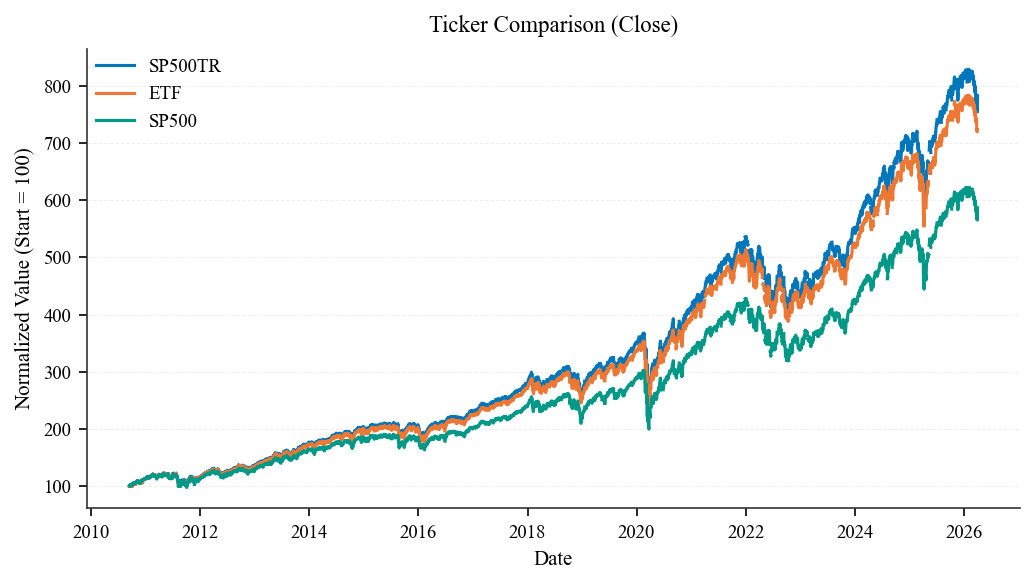

,SP500TR,ETF,SP500
Date,,,
2010-09-14,100.00000000,100.00000000,100.00000000
2010-09-15,100.35591222,100.00000000,100.35411389
2010-09-16,100.33616935,100.00000000,100.31755050
2010-09-17,100.41941377,NaN,100.40049865
2010-09-19,NaN,100.00000000,NaN
...,...,...,...
2026-03-27,757.88207705,720.99646248,568.08939759
2026-03-29,NaN,719.77179854,NaN
2026-03-30,754.89762793,723.40381832,565.84785951


In [7]:
plots.YahooFinance.compare_tickers({
    "SP500": SP500,
    "SP500TR": SP500TR,
    "ETF": ETF
}, col="Close")

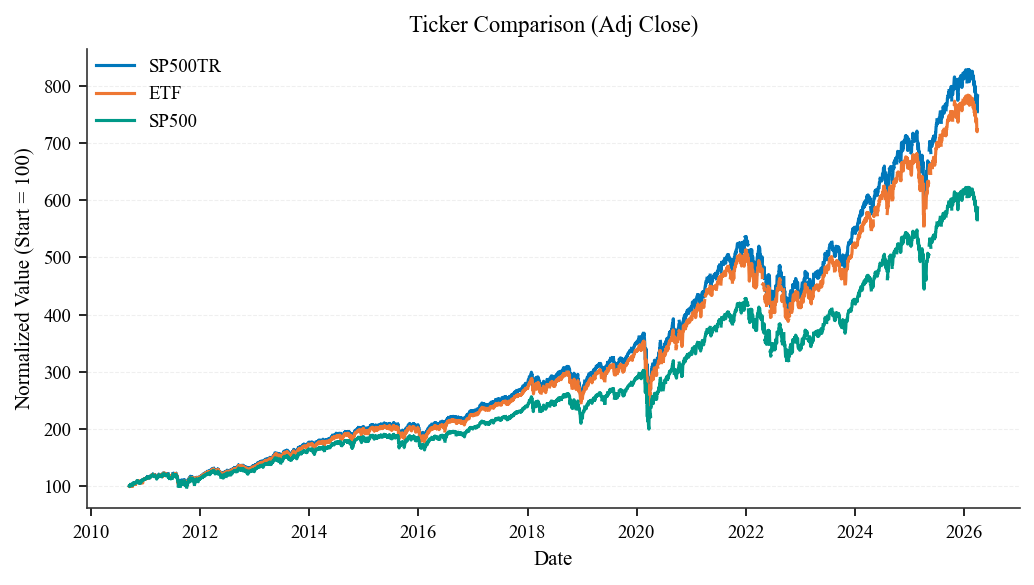

,SP500TR,ETF,SP500
Date,,,
2010-09-14,100.00000000,100.00000000,100.00000000
2010-09-15,100.35591222,100.00000000,100.35411389
2010-09-16,100.33616935,100.00000000,100.31755050
2010-09-17,100.41941377,NaN,100.40049865
2010-09-19,NaN,100.00000000,NaN
...,...,...,...
2026-03-27,757.88207705,720.99646248,568.08939759
2026-03-29,NaN,719.77179854,NaN
2026-03-30,754.89762793,723.40381832,565.84785951


In [8]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "SP500": SP500,
    "ETF": ETF
}, col="Adj Close")

Widzimy nie tylko różnicę między indeksem uwzględniającym dywidendy a tym nieuwzględniającym, ale także między indeksem total return a odpowiadającym mu ETF-em, który zwykle osiąga nieco niższe wyniki z powodu **błędu odwzorowania** (tracking error). Sam ETF nie jest więc wystarczający jako pełny benchmark historyczny, ponieważ jego najdłuższa porównywalna historia (dla ETF-u akumulującego dywidendy) rozpoczyna się dopiero około 2010 roku. Z tego powodu w analizie potrzebne są oba szeregi: **SP500TR** (długi horyzont historyczny i referencja total return) oraz **benchmark hybrydowy** (odwzorowanie realnych warunków inwestora poprzez uwzględnienie tracking error i wykorzystanie rzeczywistych notowań ETF tam, gdzie są dostępne).

#### Hybrydowy indeks S&P 500

W praktyce: SP500TR odpowiada za część historyczną (przed debiutem ETF), a hybryda zapewnia ciągłość serii i porównywalność wyników z realnym instrumentem inwestycyjnym.

Do konstrukcji hybrydowego indeksu rozważono podejścia oparte na **splicingu**, tj. łączeniu fragmentów szeregów czasowych w jedną spójną serię. Przyjęto, że w okresie dostępności ETF-u indeks hybrydowy odpowiada jego rzeczywistym notowaniom, natomiast wcześniejsze obserwacje są rekonstruowane na podstawie indeksu SP500TR.

Rozważono następujące podejścia:

1. **Proste skalowanie** — dane SP500TR są skalowane tak, aby ich wartość w punkcie łączenia była zgodna z wartością ETF-u.

2. **Bezwzględna różnica odwzorowania (tracking difference)** — w okresie wspólnym estymowana jest średnia różnica stóp zwrotu:

   $$\overline{\text{TD}} = \frac{1}{T}\sum_{t=1}^{T}(R_{\text{TR}} - R_{\text{ETF}}),$$

   która następnie koryguje historyczne stopy zwrotu:

   $$r_{\text{HYB}} = R_{\text{TR}} - \overline{\text{TD}}.$$

   Podejście to pomija jednak kumulatywny charakter błędu odwzorowania oraz jego proporcjonalność do poziomu cen.

3. **Względna różnica odwzorowania** — w okresie wspólnym estymowana jest relatywna różnica wyników ETF względem indeksu:

   $$
   TD_{annual} = \left(\frac{R_{\text{TR}}}{R_{\text{ETF}}}\right)^{\frac{252}{N}} - 1,
   $$

   gdzie $R_{\text{TR}}$ i $R_{\text{ETF}}$ oznaczają całkowite stopy zwrotu, a $N$ liczbę dni sesyjnych.

   Otrzymany parametr interpretowany jest jako średni roczny koszt odwzorowania i przekształcany do dziennego czynnika, który jest następnie kumulowany wstecznie:

   $$
   P^{adj}_t = \frac{P_t}{d^k}, \quad d = (1 + TD_{annual})^{1/252},
   $$

   gdzie $k$ oznacza liczbę dni od momentu rozpoczęcia notowań ETF.

   Tak skorygowana seria jest następnie skalowana w punkcie łączenia w celu zapewnienia ciągłości z rzeczywistymi notowaniami ETF.

Do utworzenia benchmarku przyjęto **trzecie podejście**, ponieważ pozwala ono uchwycić kumulatywny charakter błędu odwzorowania, przy jednoczesnym zachowaniu prostoty i stabilności estymacji oraz pełnej zgodności z obserwowanymi danymi ETF po dacie jego debiutu.

Loading existing benchmark from D:\Michal\Documents\Education\University\Semestr 4\Projekt indywidualny\Repo\data\processed\benchmark_2026-04-06.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 24680 entries, 1927-12-30 05:00:00+00:00 to 2026-04-02 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          24680 non-null  float64
 1   High          24680 non-null  float64
 2   Low           24680 non-null  float64
 3   Close         24680 non-null  float64
 4   Adj Close     24680 non-null  float64
 5   Volume        24680 non-null  int64  
 6   Dividends     24680 non-null  float64
 7   Stock Splits  24680 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 1.7+ MB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,24680.00000000,24680.00000000,24680.00000000,24680.00000000,24680.00000000,24680.00000000,24680.00000000,24680.00000000
mean,730.26153161,734.45782536,725.78780959,730.40359304,730.40359304,973990784.44084275,0.00000000,0.00000000
std,1252.78342243,1259.41369616,1245.59611820,1252.96226029,1252.96226029,1691694120.38679338,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,0.00000000,0.00000000
25%,24.95749950,24.95749950,24.95749950,24.95749950,24.95749950,1600000.00000000,0.00000000,0.00000000
50%,103.61500168,104.41999817,102.77500153,103.61000061,103.61000061,22310000.00000000,0.00000000,0.00000000
75%,1093.57254028,1099.52001953,1084.66751099,1093.28497314,1093.28497314,1186597500.00000000,0.00000000,0.00000000
max,7002.00000000,7002.27978516,6963.45996094,6978.60009766,6978.60009766,11456230000.00000000,0.00000000,0.00000000


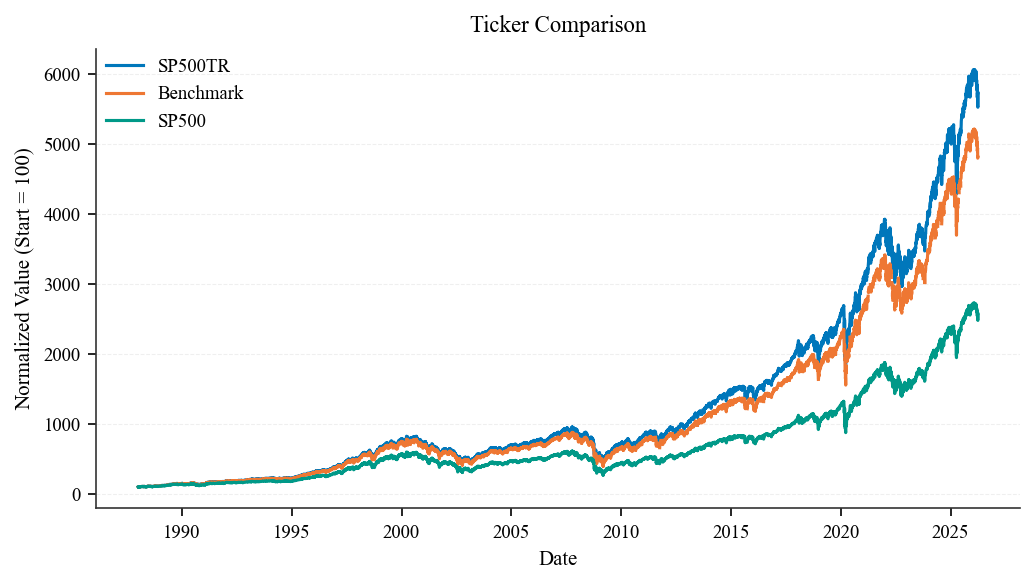

,SP500TR,Benchmark,SP500
Date,,,
1988-01-04,100.00000000,100.00000000,100.00000000
1988-01-05,101.07413488,101.07243837,101.05102853
1988-01-06,101.17569326,101.17229687,101.15261865
1988-01-07,102.02718642,102.02204899,102.00437791
1988-01-08,95.12929205,95.12290531,95.10041087
...,...,...,...
2026-03-26,5641.88773197,4876.94778507,2530.73380264
2026-03-27,5547.70753998,4797.82459965,2488.41526799
2026-03-30,5525.86133013,4813.84419430,2478.59660637


In [9]:
benchmark = features.construct_hybrid(
    long_df=SP500TR,
    short_df=ETF,
    save_csv=True,
    cleanup_old=True
)

plots.summarize_df(SP500)

plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    # "ETF": ETF, # here shows only after 2010-09-14
    "SP500": SP500
}, hide_col=True)

Poniżej przedstawiono wizualizację dwóch okresów hybrydowego indeksu:  
- **przed debiutem ETF** – historyczne notowania odtworzone na podstawie SP500TR z uwzględnieniem tracking difference.  
- **po debiucie ETF** – hybrydowy indeks pokrywa się z ETF-em.

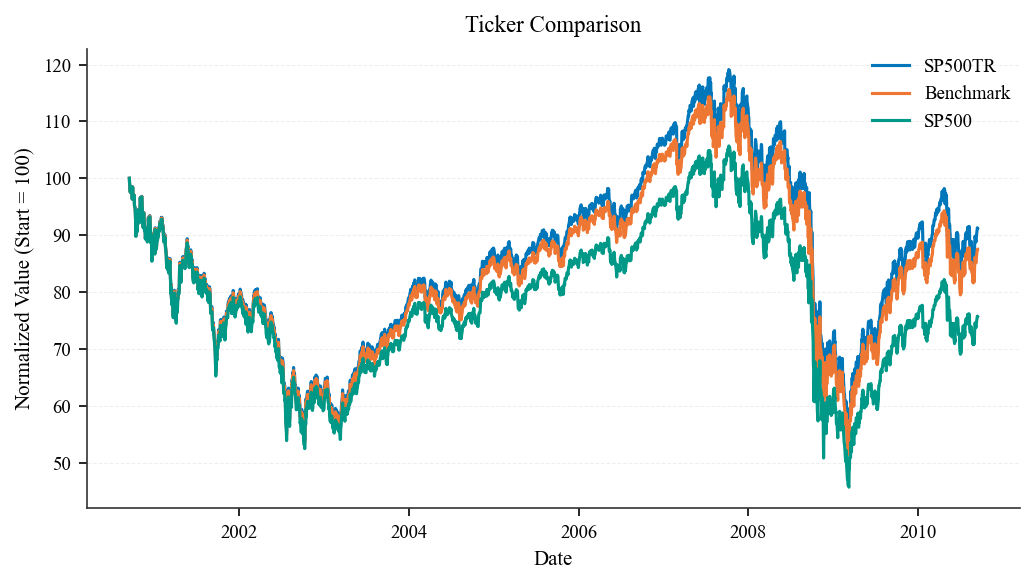

,SP500TR,Benchmark,SP500
Date,,,
2000-09-14,100.00000000,100.00000000,100.00000000
2000-09-15,98.98306332,98.98140191,98.98303453
2000-09-18,97.54650677,97.54323220,97.54468755
2000-09-19,98.58632187,98.58135770,98.58394250
2000-09-20,98.01042757,98.00384739,98.00589995
...,...,...,...
2010-09-08,89.38764760,85.70139393,74.20435276
2010-09-09,89.81993082,86.11440480,74.56292972
2010-09-10,90.25854274,86.53346929,74.92555407


In [10]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "SP500": SP500
}, hide_col=True, start_date="2000-09-14", end_date="2010-09-14")

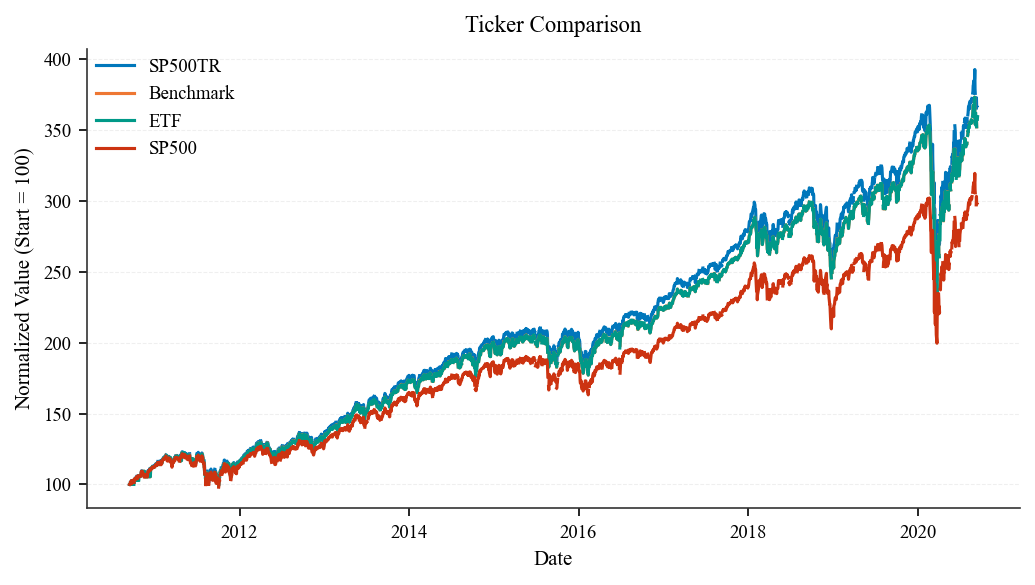

,SP500TR,Benchmark,ETF,SP500
Date,,,,
2010-09-14,100.00000000,100.00000000,100.00000000,100.00000000
2010-09-15,100.35591222,100.00000000,100.00000000,100.35411389
2010-09-16,100.33616935,100.00000000,100.00000000,100.31755050
2010-09-17,100.41941377,NaN,NaN,100.40049865
2010-09-19,NaN,NaN,100.00000000,NaN
...,...,...,...,...
2020-09-09,372.81211299,357.89197132,357.89197132,303.18080768
2020-09-10,366.27394800,352.26081701,352.26081701,297.84943485
2020-09-11,366.48686611,NaN,NaN,298.00821010


In [11]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "ETF": ETF,
    "SP500": SP500
}, hide_col=True, start_date="2010-09-14", end_date="2020-09-14")

#### S&P 500 Equal Weighted

Dla indeksu S&P 500 Equal Weighted dostępne są następujące tickery:

- **SP500EW (^SP500EW, S&P 500 Equal Weight Index)** – indeks cenowy (*price return*) równoważonej wersji S&P 500, gdzie każda spółka ma identyczny udział niezależnie od kapitalizacji
- **ETF_EW (RSP, Invesco S&P 500 Equal Weight ETF)** – fundusz ETF replikujący indeks S&P 500 z równymi wagami, akumulujący dywidendy

Na wykresie widać, że w ostatnich latach benchmark oparty na S&P 500 przewyższał ETF na S&P 500 Equal Weight. Jednak w latach przed 2018 strategia równych wag często osiągała podobne lub lepsze wyniki. Oznacza to, że relatywna efektywność podejścia equal-weight w dużej mierze zależy od siły największych spółek w indeksie.

Loading existing data for ^SP500EW from ^SP500EW.csv
Fetching new data for ^SP500EW since 2026-04-02
Updated ^SP500EW with new data
Saved data for ^SP500EW to ^SP500EW.csv
Loading existing data for RSP from RSP.csv
Fetching new data for RSP since 2026-04-02
Updated RSP with new data
Saved data for RSP to RSP.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 4844 entries, 2006-12-08 05:00:00+00:00 to 2026-04-02 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          4844 non-null   float64
 1   High          4844 non-null   float64
 2   Low           4844 non-null   float64
 3   Close         4844 non-null   float64
 4   Adj Close     4844 non-null   float64
 5   Volume        4844 non-null   int64  
 6   Dividends     4844 non-null   float64
 7   Stock Splits  4844 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 340.6+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,4844.00000000,4844.00000000,4844.00000000,4844.00000000,4844.00000000,4844.00000000,4844.00000000,4844.00000000
mean,3797.63336104,3821.42573356,3773.21482664,3798.85809547,3798.85809547,0.78447564,0.00000000,0.00000000
std,1915.82855223,1926.20570312,1906.16124926,1916.53438887,1916.53438887,54.59860284,0.00000000,0.00000000
min,824.01000977,849.15997314,810.59997559,824.01000977,824.01000977,0.00000000,0.00000000,0.00000000
25%,2025.51745605,2035.93246460,2013.15750122,2025.73995972,2025.73995972,0.00000000,0.00000000,0.00000000
50%,3341.97009277,3353.88500977,3325.14001465,3342.45495605,3342.45495605,0.00000000,0.00000000,0.00000000
75%,5588.56250000,5657.89489746,5544.03759766,5589.87487793,5589.87487793,0.00000000,0.00000000,0.00000000
max,8289.28027344,8306.87988281,8219.33984375,8290.63964844,8290.63964844,3800.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
Index: 5768 entries, 2003-05-01 04:00:00+00:00 to 2026-04-02 00:00:00-04:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           5768 non-null   float64
 1   High           5768 non-null   float64
 2   Low            5768 non-null   float64
 3   Close          5768 non-null   float64
 4   Adj Close      5768 non-null   float64
 5   Volume         5768 non-null   int64  
 6   Dividends      5768 non-null   float64
 7   Stock Splits   5768 non-null   float64
 8   Capital Gains  5768 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 450.6+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
count,5768.00000000,5768.00000000,5768.00000000,5768.00000000,5768.00000000,5768.00000000,5768.00000000,5768.00000000,5768.00000000
mean,84.94090891,85.40752771,84.41373185,84.94214158,74.65696527,2075573.83841886,0.00541349,0.00069348,0.00000000
std,47.92132521,48.15993415,47.67668983,47.92534357,49.44454647,3720040.77014652,0.05083631,0.05266807,0.00000000
min,20.59000015,21.15999985,18.00000000,20.59000015,15.51314926,4400.00000000,0.00000000,0.00000000,0.00000000
25%,43.79000092,44.06499958,43.47874928,43.75187397,32.68669796,397775.00000000,0.00000000,0.00000000,0.00000000
50%,75.55999756,75.93000031,75.13499832,75.61000061,62.40098763,780150.00000000,0.00000000,0.00000000,0.00000000
75%,111.83000183,112.34500122,111.30250168,111.74249840,100.96081734,1977925.00000000,0.00000000,0.00000000,0.00000000
max,204.27000427,205.24000549,203.17999268,204.97000122,204.09623718,57508500.00000000,0.83100000,4.00000000,0.00000000


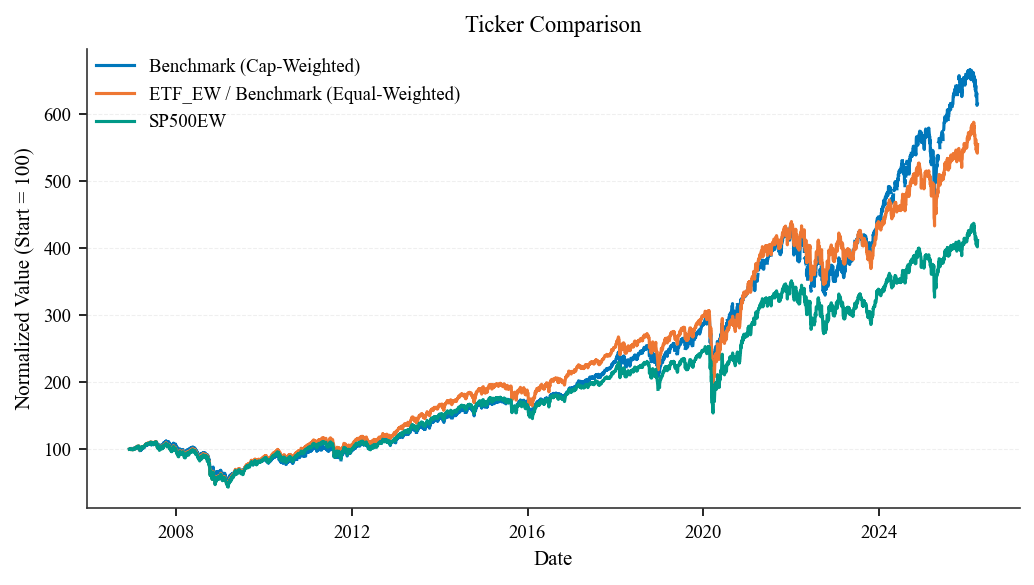

,Benchmark (Cap-Weighted),ETF_EW / Benchmark (Equal-Weighted),SP500EW
Date,,,
2006-12-08,100.00000000,100.00000000,100.00000000
2006-12-11,100.22679886,100.04200793,100.08383243
2006-12-12,100.12285680,99.89496369,99.87873422
2006-12-13,100.25659818,100.06296245,99.92091110
2006-12-14,101.13332132,100.79776614,100.74660099
...,...,...,...
2026-03-26,623.18443452,550.40475078,408.37129714
2026-03-27,613.07394334,542.85787122,402.96900028
2026-03-30,615.12095357,541.73448041,402.01465578


In [12]:
SP500EW = dataset.YahooFinance.get_ticker_data_incremental("^SP500EW", save_csv=True)
ETF_EW = dataset.YahooFinance.get_ticker_data_incremental("RSP", save_csv=True)

plots.summarize_df(SP500EW)
plots.summarize_df(ETF_EW)

plots.YahooFinance.compare_tickers({
    "Benchmark (Cap-Weighted)": benchmark,
    "ETF_EW / Benchmark (Equal-Weighted)": ETF_EW,
    "SP500EW": SP500EW,
}, hide_col=True)

Analogicznie do hybrydowego benchmarku dla S&P 500 ważonego kapitalizacją, można byłoby
skonstruować benchmark hybrydowy dla wersji equal-weighted, uwzględniając wpływ dywidend
zamiast błędu odwzorowania. W tym przypadku jednak `ETF_EW` (RSP) dysponuje najdłuższą
dostępną historią — sięgającą 2003 roku — a przedłużenie jej wstecz napotyka na istotne
ograniczenia: indeks dochodowy `SP500EWTR` nie jest dostępny w serwisie Yahoo Finance,
`SP500EW` obejmuje krótszy okres, natomiast zastosowanie benchmarku cap-weighted jako
substytutu zniekształciłoby charakterystykę strategii equal-weighted. Z tego powodu
`benchmark_ew` ograniczony jest do okresu dostępności `ETF_EW`, a porównanie obu podejść
prowadzone jest na wspólnym horyzoncie czasowym.

In [13]:
benchmark_ew = SP500EW

#### Uzyskanie danych pojedyńczych spółek

In [ ]:
yf_data: dict[str, pd.DataFrame] = dataset.YahooFinance.download_batch(sp500_components, save_csv=True)
for column_name, frame in yf_data.items():
    if frame.empty:
        print(f"{column_name}: empty")
    else:
        print(f"{column_name}: {frame.shape}, {frame.index.min().date()} -> {frame.index.max().date()}")

Number of unique tickers extracted: 1194
No new trading days since 2026-04-06.
Skipping missing ticker re-download (redownload_missing_tickers=False)
Close: (16173, 1194), 1962-01-02 -> 2026-04-06
Open: (16173, 1194), 1962-01-02 -> 2026-04-06
High: (16173, 1194), 1962-01-02 -> 2026-04-06
Low: (16173, 1194), 1962-01-02 -> 2026-04-06
Volume: (16173, 1194), 1962-01-02 -> 2026-04-06
Adj_Close: (16173, 1194), 1962-01-02 -> 2026-04-06


#### Ile danych brakuje?

Na poniższym wykresie widać, że w 1996 dane z Yahoo Finance pokrywają tylko 38%. Przy wyższym pokryciu można byłoby zastosować imputację brakujących danych, jednak jest ono na tyle małe, że konieczne będzie skorzystanie z dostawców danych, pokrywających spółki, które już nie są notowane.

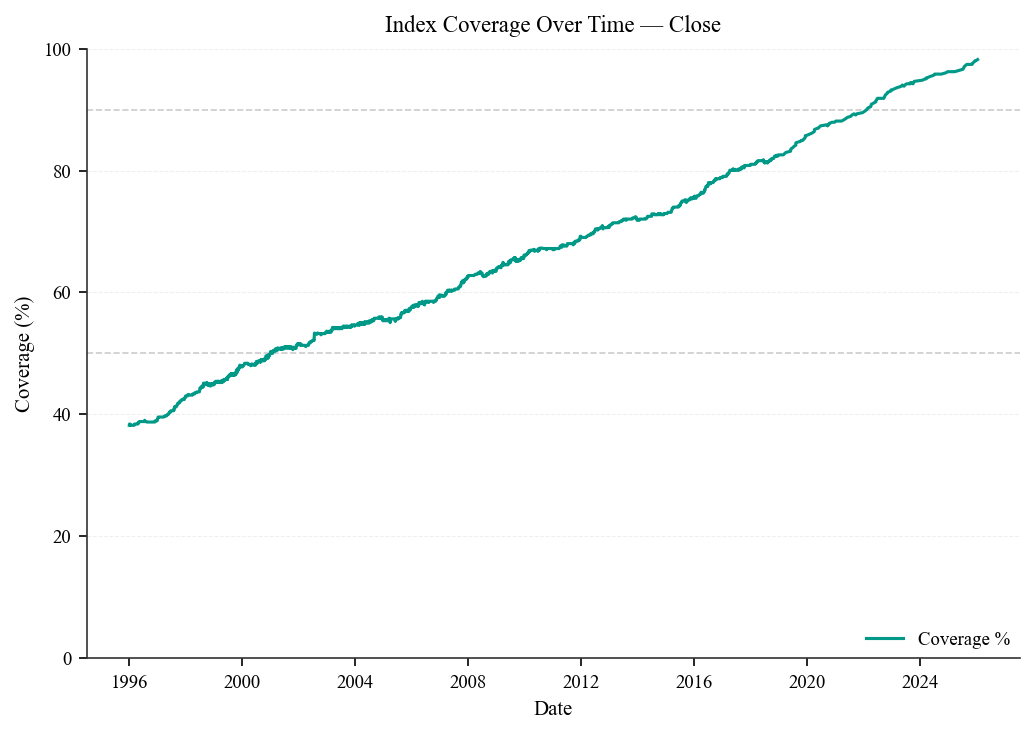

DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 2705 entries, 1996-01-02 to 2026-01-14
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   available       2705 non-null   int64  
 1   missing         2705 non-null   int64  
 2   not_downloaded  2705 non-null   int64  
 3   total           2705 non-null   int64  
 4   coverage_pct    2705 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 126.8 KB
None


,available,missing,not_downloaded,total,coverage_pct
count,2705.00000000,2705.00000000,2705.00000000,2705.00000000,2705.00000000
mean,308.11090573,188.63844732,0.00000000,496.74935305,61.89285477
std,71.22707959,66.42296669,0.00000000,5.16624733,13.73028202
min,186.00000000,9.00000000,0.00000000,487.00000000,38.19301848
25%,252.00000000,138.00000000,0.00000000,494.00000000,50.90909091
50%,309.00000000,188.00000000,0.00000000,497.00000000,62.17303823
75%,359.00000000,243.00000000,0.00000000,499.00000000,72.23340040
max,494.00000000,301.00000000,0.00000000,507.00000000,98.21073559


,available,missing,not_downloaded,total,coverage_pct
1996-01-02,186,301,0,487,38.19301848
1996-01-03,187,300,0,487,38.39835729
2025-12-22,493,10,0,503,98.01192843
2026-01-14,494,9,0,503,98.21073559


In [38]:
coverage_df = plots.coverage_over_time(yf_data, sp500_components)
plots.summarize_df(coverage_df)

### Dane cenowe z EODHD

Na EODHD dostępnych jest kilka tickerów, dla których można korzystać z danych bezpłatnie. W przypadku akcji amerykańskich są to:
- AAPL.US
- TSLA.US
- VTI.US
- AMZN.US

In [ ]:
api_key = "demo"
free_tickers = ["AAPL.US", "TSLA.US", "VTI.US", "AMZN.US"]

eodhd_data_free_tickers: dict[str, pd.DataFrame] = dataset.EODHD.download_tickers(
    tickers=free_tickers,
    api_key=api_key,
    save_csv=True
)

for column_name, frame in eodhd_data_free_tickers.items():
    if frame.empty:
        print(f"{column_name}: empty")
    else:
        print(f"{column_name}: {frame.shape}, {frame.index.name or 'Date'}: {frame.index.min().date()} -> {frame.index.max().date()}")

Number of unique tickers extracted: 4
No new trading days since 2026-04-06.
Skipping missing ticker re-download (redownload_missing_tickers=False)
EODHD per-ticker status:
  AAPL.US: skipped_already_up_to_date
  AMZN.US: skipped_already_up_to_date
  TSLA.US: skipped_already_up_to_date
  VTI.US: skipped_already_up_to_date
Close: (14126, 6), Date: 1980-12-12 -> 2026-04-06
Open: (14126, 6), Date: 1980-12-12 -> 2026-04-06
High: (14126, 6), Date: 1980-12-12 -> 2026-04-06
Low: (14126, 6), Date: 1980-12-12 -> 2026-04-06
Volume: (14126, 6), Date: 1980-12-12 -> 2026-04-06
Adj_Close: (14126, 6), Date: 1980-12-12 -> 2026-04-06


In [ ]:
eodhd_data: dict[str, pd.DataFrame] = dataset.EODHD.download(sp500_components, save_csv=True)

In [ ]:
for column_name, frame in eodhd_data.items():
    if frame.empty:
        print(f"{column_name}: empty")
    else:
        print(f"{column_name}: {frame.shape}, {frame.index.min().date()} -> {frame.index.max().date()}")

In [ ]:
coverage_df = plots.coverage_over_time(eodhd_data, sp500_components)
plots.summarize_df(coverage_df)